# First-Quadrant I-V Physical Modeling

In [1]:
# Import the measured-data loader, surface PINN, and physical channel-current model.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from DeviceData import load_iv_characteristics
from SurfacePotential import load_surface_potential_pkl, surface_potential, save_surface_potential_pkl
from physics_loss import physics_loss
from Channel_Current_Ich import effective_vds, channel_current_physical
from IVPhysicalModel import IVPhysicalParameters, save_iv_physical_pkl


## Data and physical parameters

In [2]:
# Locate the project data and load output plus transfer characteristics.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"

dataset = load_iv_characteristics(TEMPLATE_DIR, transfer_vds=20.0)
print(dataset.groupby(["characteristic", "T_C"]).size())
print("Total I-V points =", len(dataset))

def to_tensor(name):
    return torch.tensor(dataset[name].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)

Vgs_data = to_tensor("Vgs")
Vds_data = to_tensor("Vds")
T_K_data = to_tensor("T_K")
Ids_data = to_tensor("Ids")
output_mask = torch.tensor((dataset["characteristic"] == "output").to_numpy(), device=device)
transfer_mask = torch.tensor((dataset["characteristic"] == "transfer").to_numpy(), device=device)


characteristic  T_C   
output          -55.0     165
                 25.0     157
                 150.0    168
transfer        -55.0      28
                 25.0      27
                 150.0     26
dtype: int64
Total I-V points = 571


In [3]:
# Use the same surface-potential constants as the PINN pretraining stage.
NA = 1.0e16
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Eg = 3.26
Ec_minus_Ei = Eg / 2.0
Qox = 1.602e-7

surface_model, surface_checkpoint = load_surface_potential_pkl(
    BASE_DIR / "phis_PINN.pkl",
    device=device,
    dtype=dtype,
    freeze=False,
)
iv_parameters = IVPhysicalParameters(Lch_cm=1.0e-4).to(device=device, dtype=dtype)


## Unified AD-based parameter optimization

In [4]:
# Evaluate the complete surface-potential-based I-V model.
def evaluate_iv(Vgs, Vds, T_K):
    values = iv_parameters.values(Vgs, T_K)
    Vdseff = effective_vds(Vds, values["Vdssat"], values["delta"])
    phis_s0 = surface_potential(
        surface_model,
        Vgs,
        torch.zeros_like(Vgs),
        T=T_K,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=values["Vfbs0"],
        Dit_mid=Dit_mid,
        Dit_edge=values["Dit_edge"],
        sigma_it=sigma_it,
        Eg=Eg,
    )
    phis_sL = surface_potential(
        surface_model,
        Vgs,
        Vdseff,
        T=T_K,
        NA=NA,
        eps_sic=eps_sic,
        Cox=Cox,
        Vfbs0=values["Vfbs0"],
        Dit_mid=Dit_mid,
        Dit_edge=values["Dit_edge"],
        sigma_it=sigma_it,
        Eg=Eg,
    )
    Ids, mu_eff, I_phi = channel_current_physical(
        Vgs,
        Vds,
        Vdseff,
        phis_s0,
        phis_sL,
        Vfbs0=values["Vfbs0"],
        Cox=Cox,
        Qox=Qox,
        Dit_mid=Dit_mid,
        Dit_edge=values["Dit_edge"],
        sigma_it=sigma_it,
        Ec_minus_Ei=Ec_minus_Ei,
        T=T_K,
        NA=NA,
        Eg=Eg,
        eps_sic=eps_sic,
        K_current_gain=values["K"],
        mu_lf_cm2_Vs=values["mu_lf"],
        lambda_clm=values["lambda_clm"],
        Lch_cm=values["Lch_cm"],
        vsat_cm_s=values["vsat"],
    )
    return Ids, Vdseff, phis_s0, phis_sL, mu_eff, I_phi


In [5]:
# Jointly fine-tune the surface PINN and optimize the physical I-V parameters.
EPOCHS = 4000
LEARNING_RATE = 1.0e-4
PI_WEIGHT = 1.0e-5
CURRENT_SCALE = max(float(np.abs(dataset["Ids"]).max()), 1.0)
optimizer = torch.optim.Adam(
    list(surface_model.parameters()) + list(iv_parameters.parameters()),
    lr=LEARNING_RATE,
)
loss_history = []
best_loss = float("inf")
best_surface_state = None
best_iv_state = None

for epoch in range(EPOCHS):
    optimizer.zero_grad(set_to_none=True)
    Ids_pred, Vdseff, phis_s0, phis_sL, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)
    output_loss = torch.mean(((Ids_pred[output_mask] - Ids_data[output_mask]) / CURRENT_SCALE) ** 2)
    transfer_loss = torch.mean(((Ids_pred[transfer_mask] - Ids_data[transfer_mask]) / CURRENT_SCALE) ** 2)
    values = iv_parameters.values(Vgs_data, T_K_data)
    pi_source = physics_loss(
        phis_s0,
        Vgs_data,
        torch.zeros_like(Vgs_data),
        T_K_data,
        NA,
        eps_sic,
        Cox,
        values["Vfbs0"],
        Qox,
        Dit_mid,
        values["Dit_edge"],
        sigma_it,
        Ec_minus_Ei,
        Eg,
    )
    pi_drain = physics_loss(
        phis_sL,
        Vgs_data,
        Vdseff,
        T_K_data,
        NA,
        eps_sic,
        Cox,
        values["Vfbs0"],
        Qox,
        Dit_mid,
        values["Dit_edge"],
        sigma_it,
        Ec_minus_Ei,
        Eg,
    )
    loss = 0.5 * output_loss + 0.5 * transfer_loss + PI_WEIGHT * 0.5 * (pi_source + pi_drain)
    if not torch.isfinite(loss):
        raise RuntimeError(f"Non-finite loss at epoch {epoch}")
    loss.backward()
    torch.nn.utils.clip_grad_norm_(surface_model.parameters(), max_norm=10.0)
    torch.nn.utils.clip_grad_norm_(iv_parameters.parameters(), max_norm=10.0)
    optimizer.step()
    value = loss.item()
    loss_history.append(value)
    if value < best_loss:
        best_loss = value
        best_surface_state = {k: v.detach().cpu().clone() for k, v in surface_model.state_dict().items()}
        best_iv_state = {k: v.detach().cpu().clone() for k, v in iv_parameters.state_dict().items()}
    if epoch % 200 == 0 or epoch == EPOCHS - 1:
        rmse = torch.sqrt(torch.mean((Ids_pred.detach() - Ids_data) ** 2)).item()
        print(f"Epoch {epoch:4d} | loss = {value:.6e} | RMSE = {rmse:.4f} A")

surface_model.load_state_dict(best_surface_state, strict=True)
iv_parameters.load_state_dict(best_iv_state, strict=True)
print("Best loss =", best_loss)
print(pd.DataFrame(iv_parameters.report()))


Epoch    0 | loss = 7.088497e-02 | RMSE = 19.5356 A
Epoch  200 | loss = 2.154936e-02 | RMSE = 9.1178 A
Epoch  400 | loss = 1.792832e-02 | RMSE = 8.4516 A
Epoch  600 | loss = 1.658859e-02 | RMSE = 8.1991 A
Epoch  800 | loss = 1.558612e-02 | RMSE = 7.9399 A
Epoch 1000 | loss = 1.474141e-02 | RMSE = 7.7027 A
Epoch 1200 | loss = 1.400112e-02 | RMSE = 7.4915 A
Epoch 1400 | loss = 1.333411e-02 | RMSE = 7.3017 A
Epoch 1600 | loss = 1.271614e-02 | RMSE = 7.1263 A
Epoch 1800 | loss = 1.212358e-02 | RMSE = 6.9575 A
Epoch 2000 | loss = 1.153083e-02 | RMSE = 6.7852 A
Epoch 2200 | loss = 1.090086e-02 | RMSE = 6.5944 A
Epoch 2400 | loss = 1.017260e-02 | RMSE = 6.3581 A
Epoch 2600 | loss = 9.243350e-03 | RMSE = 6.0304 A
Epoch 2800 | loss = 8.012297e-03 | RMSE = 5.5742 A
Epoch 3000 | loss = 6.622181e-03 | RMSE = 5.0681 A
Epoch 3200 | loss = 5.487948e-03 | RMSE = 4.6976 A
Epoch 3400 | loss = 4.794025e-03 | RMSE = 4.5179 A
Epoch 3600 | loss = 4.390589e-03 | RMSE = 4.4220 A
Epoch 3800 | loss = 4.114702e-

## Save the refined PINN and physical I-V parameters

In [6]:
# Save the neural network and physical parameters as structured PyTorch .pkl files.
save_surface_potential_pkl(
    BASE_DIR / "phis_PINN_IV_refined.pkl",
    surface_model,
    physical_parameters=surface_checkpoint.get("physical_parameters", {}),
    training_metadata={"joint_IV_best_loss": best_loss, "joint_IV_epochs": EPOCHS},
)
save_iv_physical_pkl(
    BASE_DIR / "Ich_physical.pkl",
    iv_parameters,
    training_metadata={"best_loss": best_loss, "epochs": EPOCHS, "learning_rate": LEARNING_RATE},
)

bundle = {
    "format_version": 1,
    "model_name": "SiC_MOSFET_First_Quadrant_IV",
    "surface_potential_PINN": torch.load(BASE_DIR / "phis_PINN_IV_refined.pkl", map_location="cpu", weights_only=False),
    "Ich_physical": torch.load(BASE_DIR / "Ich_physical.pkl", map_location="cpu", weights_only=False),
}
torch.save(bundle, BASE_DIR / "Ich_Model.pkl")
print("Saved phis_PINN_IV_refined.pkl, Ich_physical.pkl, and Ich_Model.pkl")


Saved phis_PINN_IV_refined.pkl, Ich_physical.pkl, and Ich_Model.pkl


## Accuracy and measured-curve comparison

In [7]:
# Report the fit error on the measured output and transfer datasets.
surface_model.eval()
iv_parameters.eval()
with torch.no_grad():
    Ids_fit, _, _, _, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)
error = Ids_fit - Ids_data
print("Overall RMSE =", torch.sqrt(torch.mean(error**2)).item(), "A")
for temp_c in [-55.0, 25.0, 150.0]:
    temp_mask = torch.tensor(np.isclose(dataset["T_C"].to_numpy(), temp_c), device=device)
    temp_error = error[temp_mask]
    print(f"Tj = {temp_c:g} C | RMSE = {torch.sqrt(torch.mean(temp_error**2)).item():.4f} A")


Overall RMSE = 4.26028299331665 A
Tj = -55 C | RMSE = 5.2229 A
Tj = 25 C | RMSE = 3.0635 A
Tj = 150 C | RMSE = 4.1691 A


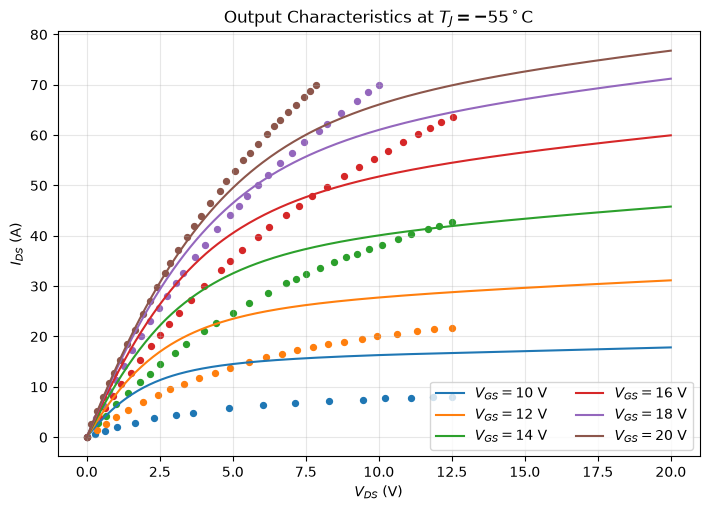

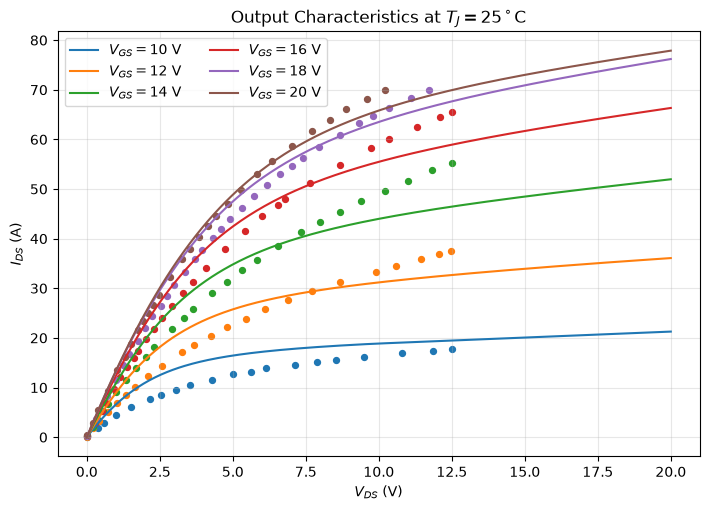

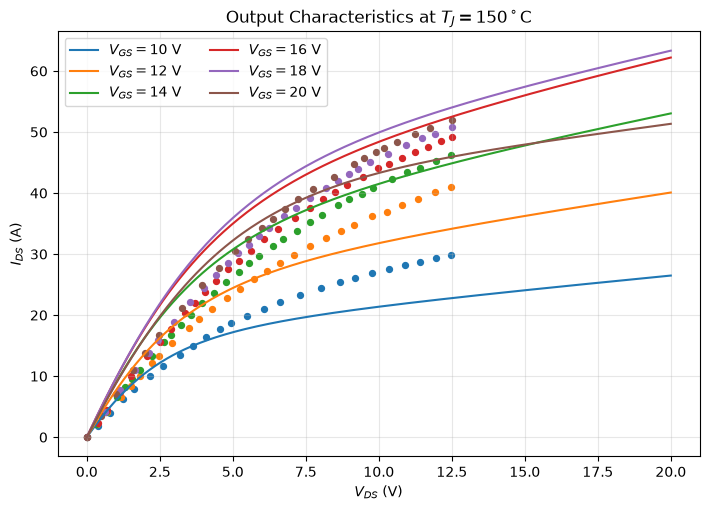

In [8]:
# Plot the measured and modeled output characteristics.
def predict_curve(vgs_value, temp_c, vds_max=20.0, points=300):
    Vds = torch.linspace(0.0, vds_max, points, dtype=dtype, device=device).reshape(-1, 1)
    Vgs = torch.full_like(Vds, float(vgs_value))
    T_K = torch.full_like(Vds, float(temp_c + 273.15))
    with torch.no_grad():
        Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
    return Vds.cpu().numpy().reshape(-1), Ids.cpu().numpy().reshape(-1)

for temp_c in [-55.0, 25.0, 150.0]:
    plt.figure(figsize=(7.2, 5.2))
    part_t = dataset[(dataset["characteristic"] == "output") & np.isclose(dataset["T_C"], temp_c)]
    for vgs_value in sorted(part_t["Vgs"].unique()):
        measured = part_t[np.isclose(part_t["Vgs"], vgs_value)]
        plt.scatter(measured["Vds"], measured["Ids"], s=18)
        x, y = predict_curve(vgs_value, temp_c, vds_max=max(20.0, measured["Vds"].max()))
        plt.plot(x, y, label=rf"$V_{{GS}}={vgs_value:g}$ V")
    plt.xlabel(r"$V_{DS}$ (V)")
    plt.ylabel(r"$I_{DS}$ (A)")
    plt.title(rf"Output Characteristics at $T_J={temp_c:g}^\circ$C")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


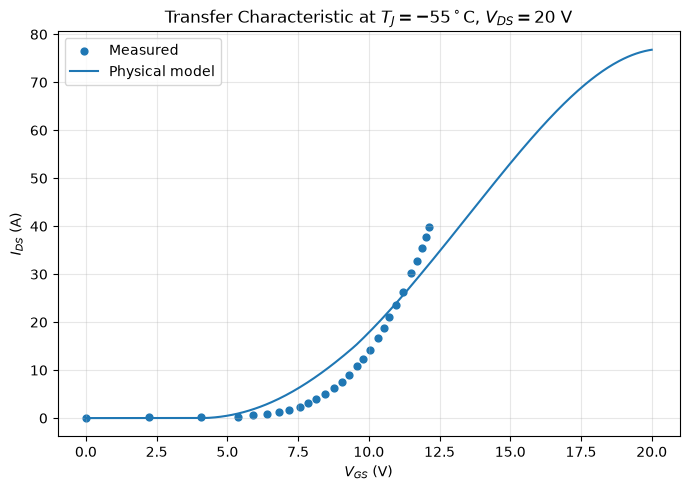

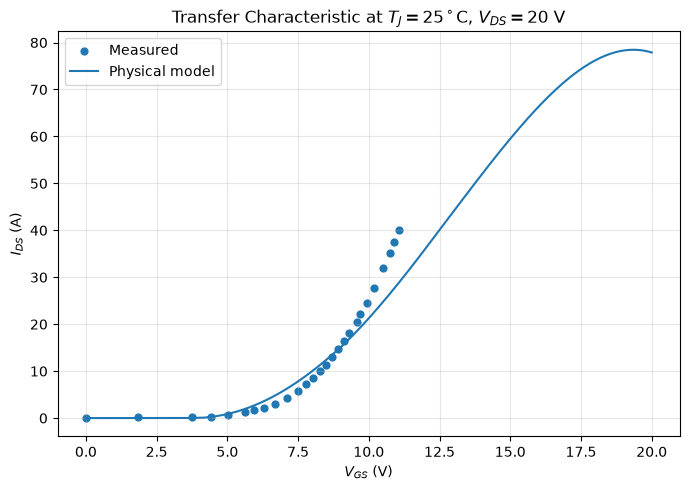

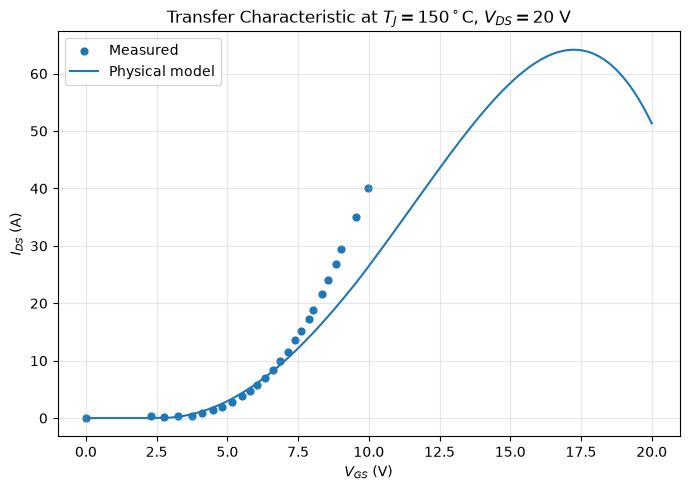

In [9]:
# Plot the measured and modeled transfer characteristics.
for temp_c in [-55.0, 25.0, 150.0]:
    measured = dataset[(dataset["characteristic"] == "transfer") & np.isclose(dataset["T_C"], temp_c)]
    Vgs = torch.linspace(0.0, 20.0, 400, dtype=dtype, device=device).reshape(-1, 1)
    Vds = torch.full_like(Vgs, 20.0)
    T_K = torch.full_like(Vgs, float(temp_c + 273.15))
    with torch.no_grad():
        Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
    plt.figure(figsize=(7.0, 5.0))
    plt.scatter(measured["Vgs"], measured["Ids"], s=24, label="Measured")
    plt.plot(Vgs.cpu(), Ids.cpu(), label="Physical model")
    plt.xlabel(r"$V_{GS}$ (V)")
    plt.ylabel(r"$I_{DS}$ (A)")
    plt.title(rf"Transfer Characteristic at $T_J={temp_c:g}^\circ$C, $V_{{DS}}=20$ V")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


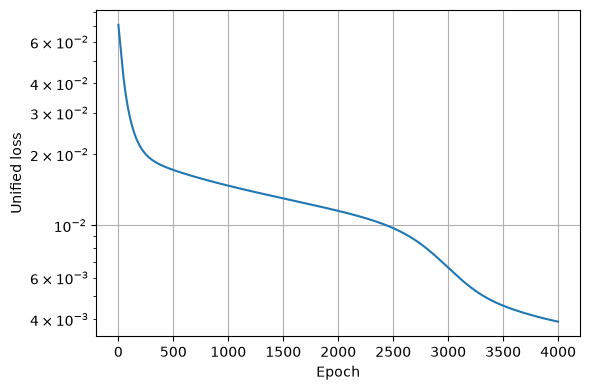

In [10]:
# Plot the training objective.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Unified loss")
plt.grid(True)
plt.tight_layout()
plt.show()
